In [8]:
!pip install uvtools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 3.7 MB/s eta 0:00:0000:0100:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for uvtools: filename=uvtools-0.2.0-py3-none-any.whl size=4492825 sha256=113698cec84ab8380384b17b0c6327ad51770f63d24d8f3c85a6577ed415339f
  Stored in directory: /Users/user/Library/Caches/pip/wheels/14/a6/82/68d9cbf06b9a6c2543e28d0825ae38636ab01d3878c425c2f5
Successfully built uvtools


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hera_sim
from hera_sim import Simulator

In [2]:
from pyuvdata import UVData

In [3]:
from uvtools.plot import labeled_waterfall

In [4]:
def waterfall(sim, antpairpol=(0,1,"xx"), figsize=(6,3.5), dpi=200, title=None):
    """Convenient plotting function to show amp/phase."""
    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        dpi=dpi,
    )
    fig, ax1 = labeled_waterfall(
        sim.data,
        antpairpol=antpairpol,
        mode="log",
        ax=ax1,
        set_title=title,
    )
    ax1.set_xlabel(None)
    ax1.set_xticklabels(['' for tick in ax1.get_xticks()])
    fig, ax2 = labeled_waterfall(
        sim.data,
        antpairpol=antpairpol,
        mode="phs",
        ax=ax2,
        set_title=False,
    )
    return fig

In [6]:
UV = UVData()

#Foregrounds + EoR signal
UV.read(filename='/Users/user/Documents/Codes/hydra-pspec/test_data/vis-eor-fgs.uvh5')

Telescope Hex37-14.6m is not in known_telescopes.


In [7]:
sim = Simulator(data=UV.copy())
hera_sim.defaults.set("h1c")

The use_grid_alg parameter is not set. Defaulting to True to use the new gridding based algorithm (developed by the HERA team) rather than the older clustering based algorithm. This is change to the default, to use the clustering algorithm set use_grid_alg=False.


set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


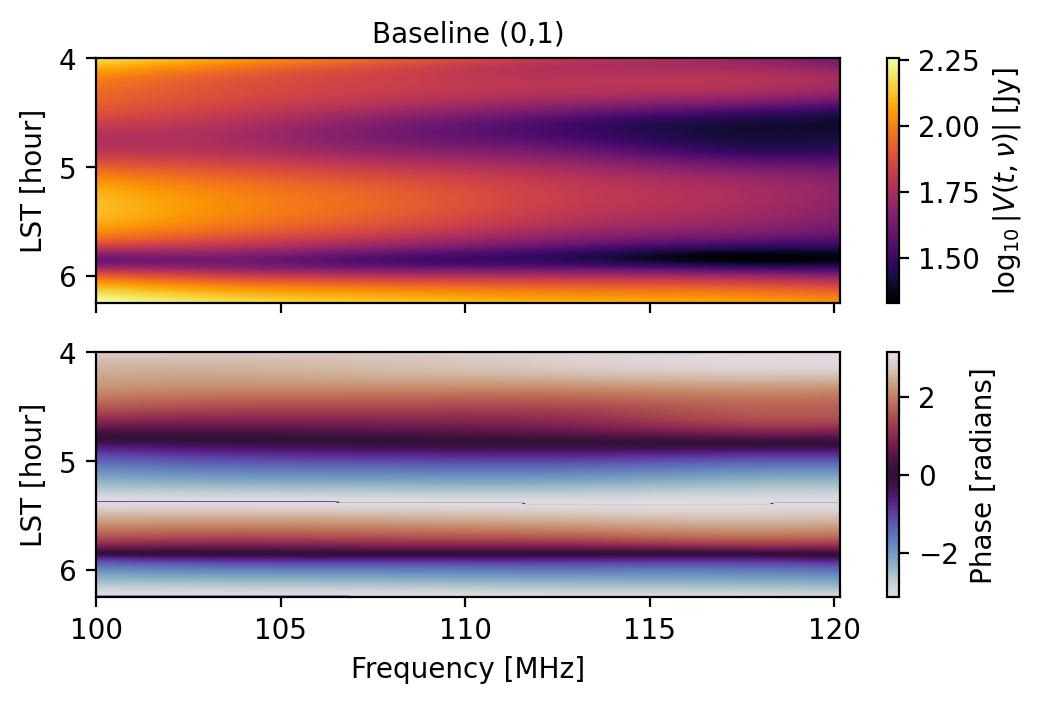

In [8]:
#Plot true data
fig1 = waterfall(sim, antpairpol=(0,1,"xx"), title="Baseline (0,1)")

### Add Systematics

In [9]:
#Gains
sim.add(component="gains",seed=1585957365)

In [10]:
#10 coupling peaks with randomisation
sim.add(component="CrossCouplingSpectrum", n_copies=10,
            amp_range=(-4,-6), dly_range=(900,1300), phs_range=(-np.pi,np.pi),
                amp_jitter=0.01, dly_jitter=20, seed=1585964131, symmetrize=True)

You are adding visibilities to a data array *after* multiplicative effects have been introduced.


KeyError: 'Antenna pair (0, 0) not found in data'

In [17]:
#Reflection spectrum/20 subreflections
sim.add(component="reflection_spectrum", n_copies=20,
            amp_range=(-3,-4), dly_range=(200,1000), phs_range=(-np.pi,np.pi), 
            amp_jitter=0.01, dly_jitter=30, seed=2440572501)

In [18]:
#2 high-amplitude reflections
sim.add(component="reflections",amp=0.003,amp_jitter=0.01,dly=200,dly_jitter=10,seed=2440572505)
sim.add(component="reflections",amp=0.0008,amp_jitter=0.01,dly=1200,dly_jitter=30,seed=2440572506)

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


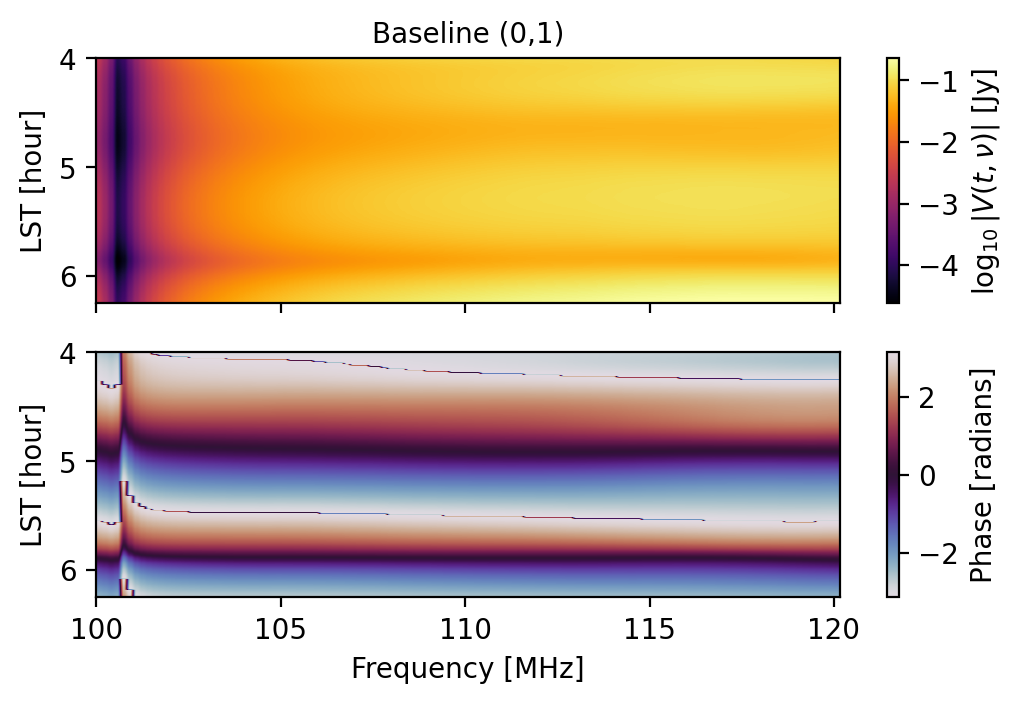

In [19]:
#Plot corrupted data
fig2 = waterfall(sim, antpairpol=(0,1,"xx"), title="Baseline (0,1)")

In [20]:
#Save corrupted data
sim.write('vis-eor-fgs-corrupt.uvh5', save_format="uvh5", fix_autos=True, clobber=True)